# Gradland: a computational companion

This notebook works through the technical ideas in *Gradland: On Phenomenal
Experience, Differentiated Across Many Dimensions*, using the
libraries in this directory (`jacobians.py`, `jacobian_measures.py`). It follows
the paper's ordering: Jacobians, then the two measures (transparency
and cohesion), then a selection of the worked examples of §"Living in
Gradland".

Section 4 works through the **metabolic channel** from the 
*Metabolic Fire: Minimal Models of Affect, Purpose and Norms*.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import matplotlib as mpl

from jacobians import jacobian, capture, select_params, input_jacobian, parameter_jacobian
from jacobian_measures import (
    transparency, cohesion, cohesion_normalized, cohesive_rank, luminosity,
    cohesive_luminosity, effective_rank, normalized_kirchhoff,
)

torch.manual_seed(0)
np.random.seed(0)
DTYPE = torch.float64
torch.set_default_dtype(DTYPE)

mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["axes.grid"] = False


def heat(ax, A, title=None, cmap="RdBu_r", symmetric=True, cbar=True):
    """Small helper: heatmap a matrix with a diverging colormap centered at 0."""
    A = A.detach().numpy() if torch.is_tensor(A) else np.asarray(A)
    vmax = np.abs(A).max() if symmetric else A.max()
    vmin = -vmax if symmetric else A.min()
    im = ax.imshow(A, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    if title:
        ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    if cbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im

## 1. Jacobians

§"Jacobians" and §"The experience of physically interacting" define, for a system with inputs $x$, parameters $W$, outputs $y$, the **input Jacobian** and the **parameter Jacobian**. `jacobians.py` computes both for an arbitrary `nn.Module`, letting you pick *which neurons* count as inputs and outputs.

In [2]:
def relu_mlp(dims, generator):
    layers = []
    for i in range(len(dims) - 1):
        layers.append(nn.Linear(dims[i], dims[i + 1]))
        if i < len(dims) - 2:
            layers.append(nn.ReLU())
    net = nn.Sequential(*layers)
    with torch.no_grad():
        for p in net.parameters():
            p.copy_(torch.randn(p.shape, generator=generator) * 0.8)
    return net

g = torch.Generator().manual_seed(2)
mlp = relu_mlp([4, 6, 5, 3], g)
x = torch.randn(4, generator=g)

J_x = input_jacobian(mlp, x)
J_w = parameter_jacobian(mlp, x)
print("J_{y<-x} shape:", tuple(J_x.shape))
print("J_{y<-W} shape:", tuple(J_w.shape), " (all", sum(p.numel() for p in mlp.parameters()), "parameters)")

# finite-difference check
eps = 1e-6
with torch.no_grad():
    y0 = mlp(x)
    J_fd = torch.zeros(3, 4)
    for j in range(4):
        dx = x.clone(); dx[j] += eps
        J_fd[:, j] = (mlp(dx) - y0) / eps
print("max |J_x - finite differences| =", (J_x - J_fd).abs().max().item())

J_{y<-x} shape: (3, 4)
J_{y<-W} shape: (3, 83)  (all 83 parameters)
max |J_x - finite differences| = 1.2603906807129306e-10


`input_jacobian`/`parameter_jacobian` also accept `output_names`/`input_names`
to point at *any* named submodule, not just the model's raw input/output --
this is how the paper lets a "system" be any subgraph with chosen input and
output nodes (§"Notation and basics").

In [3]:
# J_{y <- a_l}: Jacobian from the activation *after* the first ReLU (module "1")
# to the final output y.
J_al = input_jacobian(mlp, x, input_names=["1"])
print('J_{y<-a_1} shape:', tuple(J_al.shape), "-- 3 outputs, 6 hidden units after layer 1")

J_{y<-a_1} shape: (3, 6) -- 3 outputs, 6 hidden units after layer 1


### Composition and path sums

By the chain rule, Jacobians are products of matrices, and the
Jacobian entry $J_{ij}$ is a sum over paths from input $i$ to output $j$ of
the product of weights along the path -- restricted, for a relu net, to
*active* paths only.

In [4]:
W1 = torch.randn(6, 4, generator=g)
W2 = torch.randn(3, 6, generator=g)

# relu net: the Jacobian equals the linear map through only the *active* units
x_relu = torch.randn(4, generator=g, requires_grad=True)
a1 = W1 @ x_relu
z1 = torch.relu(a1)
y_relu = W2 @ z1
J_relu = jacobian(y_relu, x_relu)

active = (a1 > 0).double()                 # which of the 6 hidden units are "on"
J_active_paths = W2 @ torch.diag(active) @ W1   # sum over active paths only
print("max |J_relu - active-path formula| =", (J_relu - J_active_paths).abs().max().item())
print("active units:", active.numpy().astype(int))

max |J_relu - active-path formula| = 2.220446049250313e-16
active units: [1 0 0 1 1 0]


## 2. Quantifying experience: transparency, cohesion, cohesive rank

§"Quantifying experience" introduces two measures on a matrix $A$ (in practice always a Jacobian):

- **Transparency** (the *effective rank*): how many roughly equal-sized "impressions" pass through the matrix. Low = one vivid channel; high = many, equally vivid.
- **Cohesion**: how tangled the rows and columns are -- zero iff $A$ is block diagonal (up to permutation), i.e. iff it decomposes into independent, non-interacting subsystems.

**Cohesive rank** combines them: it is zero unless the matrix is both transparent *and* cohesive.

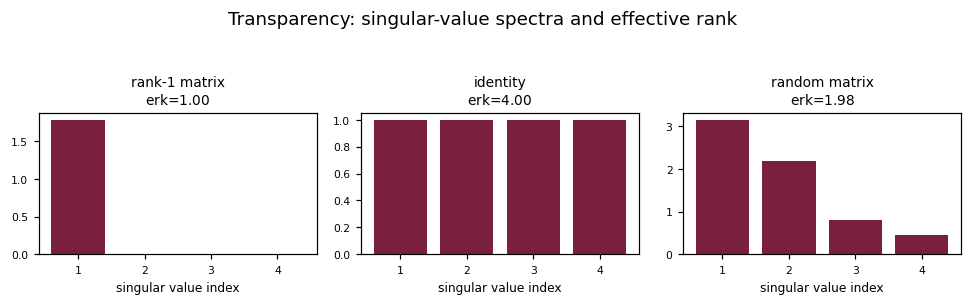

In [5]:
def spectrum_and_erk(A, label, ax):
    s = torch.linalg.svdvals(A)
    ax.bar(range(1, len(s) + 1), s.numpy(), color="#7a1f3d")
    ax.set_title(f"{label}\n$\\mathrm{{erk}}$={transparency(A).item():.2f}", fontsize=9)
    ax.set_xlabel("singular value index", fontsize=8)
    ax.tick_params(labelsize=7)

g = torch.Generator().manual_seed(3)
n = 4
A_rank1 = torch.outer(torch.randn(n, generator=g), torch.randn(n, generator=g))
A_identity = torch.eye(n)
A_random = torch.randn(n, n, generator=g)

fig, axes = plt.subplots(1, 3, figsize=(9, 2.6))
spectrum_and_erk(A_rank1, "rank-1 matrix", axes[0])
spectrum_and_erk(A_identity, "identity", axes[1])
spectrum_and_erk(A_random, "random matrix", axes[2])
fig.suptitle("Transparency: singular-value spectra and effective rank", y=1.05)
fig.tight_layout()
plt.show()

Effective rank is exactly 1 for a rank-1 matrix (one dominant singular
value), exactly $n$ for the identity (all singular values equal), and
somewhere in between for a generic random matrix.

### Cohesion, block diagonal, dense

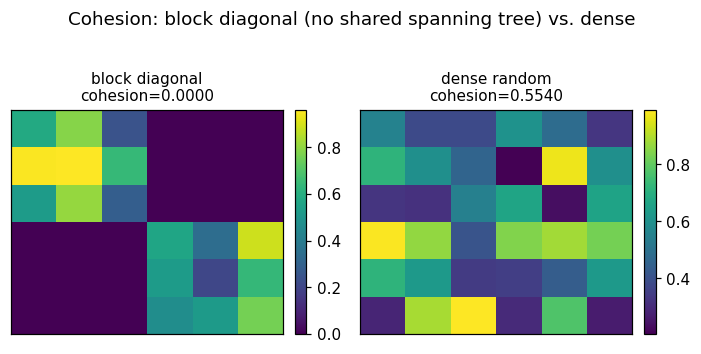

In [6]:
g = torch.Generator().manual_seed(4)
n1, n2 = 3, 3
block1 = torch.rand(n1, n1, generator=g) * 0.8 + 0.2
block2 = torch.rand(n2, n2, generator=g) * 0.8 + 0.2
A_block = torch.zeros(n1 + n2, n1 + n2)
A_block[:n1, :n1] = block1
A_block[n1:, n1:] = block2
A_dense = torch.rand(n1 + n2, n1 + n2, generator=g) * 0.8 + 0.2

fig, axes = plt.subplots(1, 2, figsize=(6.5, 3))
heat(axes[0], A_block, f"block diagonal\ncohesion={cohesion(A_block).item():.4f}", cmap="viridis", symmetric=False)
heat(axes[1], A_dense, f"dense random\ncohesion={cohesion(A_dense).item():.4f}", cmap="viridis", symmetric=False)
fig.suptitle("Cohesion: block diagonal (no shared spanning tree) vs. dense", y=1.03)
fig.tight_layout()
plt.show()

A block-diagonal matrix has cohesion (numerically) zero: its bipartite
graph is disconnected, so it has no spanning tree at all. A dense matrix's
bipartite graph is fully connected, giving many spanning trees and cohesion
bounded away from zero.

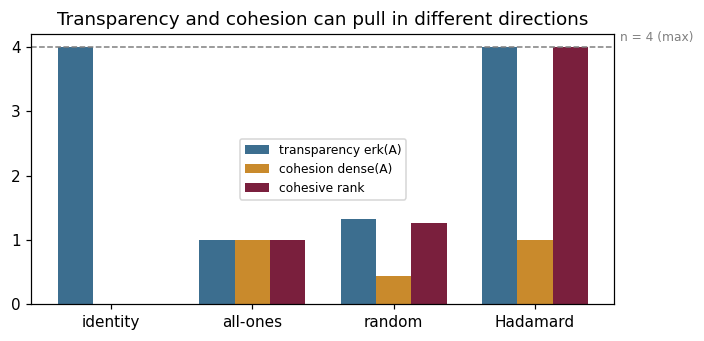

In [7]:
# Cohesive rank pulls transparency and cohesion together. The identity
# maximizes transparency but has zero cohesion; the all-ones matrix
# maximizes cohesion but has effective rank 1; a Hadamard matrix (entries
# +-1, orthogonal rows/cols) maximizes *both*, hitting the paper's claimed
# bound dense_erk(A) = n for an n x n matrix.
n = 4
H = torch.tensor([
    [1., 1, 1, 1],
    [1, -1, 1, -1],
    [1, 1, -1, -1],
    [1, -1, -1, 1],
])
candidates = {
    "identity": torch.eye(n),
    "all-ones": torch.ones(n, n),
    "random": torch.rand(n, n, generator=torch.Generator().manual_seed(5)),
    "Hadamard": H,
}
names = list(candidates)
erks = [transparency(candidates[k]).item() for k in names]
cohs = [cohesion(candidates[k]).item() for k in names]
cranks = [cohesive_rank(candidates[k]).item() for k in names]

x_pos = np.arange(len(names))
fig, ax = plt.subplots(figsize=(6.5, 3.2))
w = 0.25
ax.bar(x_pos - w, erks, width=w, label="transparency erk(A)", color="#3c6e8f")
ax.bar(x_pos, cohs, width=w, label="cohesion dense(A)", color="#c98a2c")
ax.bar(x_pos + w, cranks, width=w, label="cohesive rank", color="#7a1f3d")
ax.set_xticks(x_pos); ax.set_xticklabels(names)
ax.axhline(n, ls="--", c="gray", lw=1)
ax.text(3.6, n + 0.1, "n = 4 (max)", fontsize=8, color="gray")
ax.legend(fontsize=8)
ax.set_title("Transparency and cohesion can pull in different directions")
fig.tight_layout()
plt.show()

The identity is maximally transparent but has zero cohesion (its rows
don't interact); the all-ones matrix is maximally cohesive but has
effective rank 1 (one impression, repeated). The Hadamard matrix scores
well on both and attains the maximum possible cohesive rank, $n$.

### Active circuits: inactive units are not part of the system

§"Specifying systems" makes a point that matters for any relu net: a unit that is inactive for a given input contributes an exactly-zero gradient to every one of its incoming weights and its bias, so it has zero cohesion with the rest of the net -- **"the system should only include active neurons."** The maximalist parameter Jacobian (every parameter, the default starting point) reports this correctly as cohesive rank zero, but zero is uninformative here: it doesn't distinguish a genuinely disconnected net from a net that merely has some inactive units for this particular input. `jacobian_measures.drop_isolated` restricts the Jacobian to the rows/columns that actually carry gradient -- the *active circuit* -- so cohesive rank measures how the live part of the net hangs together.

parameter Jacobian shape: (4, 484), dead columns: 363/484 (75% -- every inactive unit zeroes its incoming weights and bias)
cohesive rank, maximalist system (every parameter): 0.0000
cohesive rank, active circuit only (drop_isolated):  2.1722


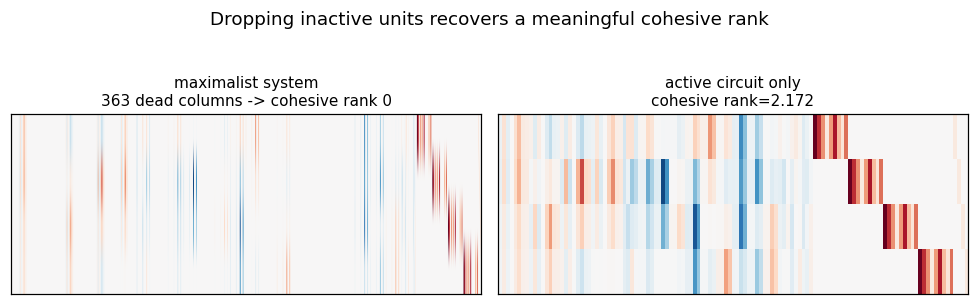

In [8]:
from jacobian_measures import drop_isolated

g = torch.Generator().manual_seed(13)
wide_relu = relu_mlp([8, 16, 16, 4], g)
x_wide = torch.randn(8, generator=g)

Jw = parameter_jacobian(wide_relu, x_wide)
dead = Jw.abs().sum(0) == 0
print(f"parameter Jacobian shape: {tuple(Jw.shape)}, dead columns: {dead.sum().item()}/{dead.numel()} "
      f"({100 * dead.float().mean().item():.0f}% -- every inactive unit zeroes its incoming weights and bias)")
print(f"cohesive rank, maximalist system (every parameter): {cohesive_rank(Jw).item():.4f}")

Jw_live = drop_isolated(Jw)
print(f"cohesive rank, active circuit only (drop_isolated):  {cohesive_rank(Jw_live).item():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 2.6))
heat(axes[0], Jw, f"maximalist system\n{dead.sum().item()} dead columns -> cohesive rank 0", cbar=False)
heat(axes[1], Jw_live, f"active circuit only\ncohesive rank={cohesive_rank(Jw_live).item():.3f}", cbar=False)
fig.suptitle("Dropping inactive units recovers a meaningful cohesive rank", y=1.05)
fig.tight_layout()
plt.show()

## 3. Living in Gradland

This section works through the paper's worked examples in
order, using `jacobian`/`cohesion`/`transparency`/`cohesive_rank` on
progressively more structured nets.

### 3.1 Weaving the world in me: you and me

§"weaving the world in me" considers two MLPs, *you* and *me*, looking at
the same input. The **input** Jacobian of the stacked outputs is dense
(our experiences overlap, since we share the tree); the **parameter**
Jacobian is block diagonal (our decisions are independent, since we don't
share parameters).

Kept to plain linear nets, no hidden layer, just so the printed matrices
below stay small enough to read at a glance.

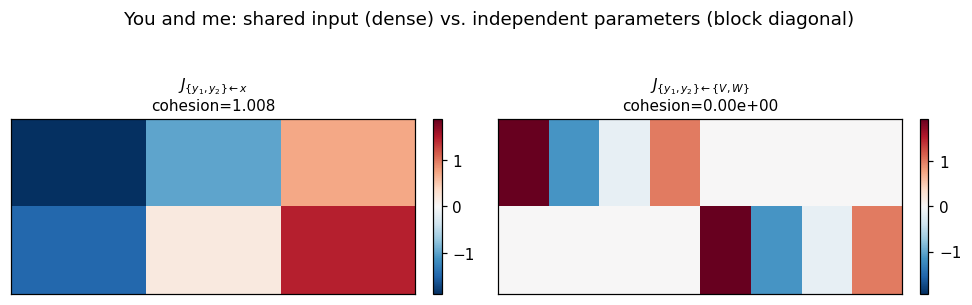

In [9]:
g = torch.Generator().manual_seed(6)
you = nn.Linear(3, 1)
me = nn.Linear(3, 1)
with torch.no_grad():
    for p in list(you.parameters()) + list(me.parameters()):
        p.copy_(torch.randn(p.shape, generator=g))
x_tree = torch.randn(3, generator=g, requires_grad=True)
y_you, y_me = you(x_tree), me(x_tree)

J_input_shared = jacobian([y_you, y_me], x_tree)
params = list(you.parameters()) + list(me.parameters())
J_param_shared = jacobian([y_you, y_me], params)

fig, axes = plt.subplots(1, 2, figsize=(9, 2.6))
heat(axes[0], J_input_shared, f"$J_{{\\{{y_1,y_2\\}}\\leftarrow x}}$\ncohesion={cohesion(J_input_shared).item():.3f}", symmetric=True)
heat(axes[1], J_param_shared, f"$J_{{\\{{y_1,y_2\\}}\\leftarrow\\{{V,W\\}}}}$\ncohesion={cohesion(J_param_shared).item():.2e}", symmetric=True)
fig.suptitle("You and me: shared input (dense) vs. independent parameters (block diagonal)", y=1.05)
fig.tight_layout()
plt.show()

### 3.2 The experience of duration

§"The experience of duration" compares an MLP applied independently at
each timestep (no interaction across time) to an RNN (interaction across
time, but only with the *past*). The MLP's Jacobian over a sequence is
diagonal and has zero cohesion; the RNN's is lower triangular and has
positive cohesion.

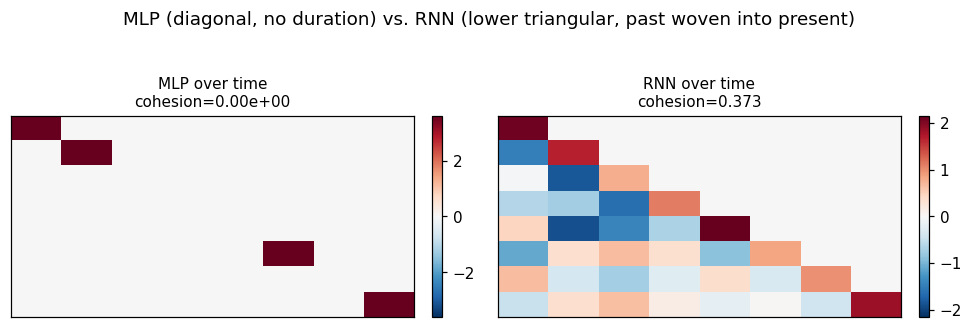

In [10]:
T = 8
g = torch.Generator().manual_seed(7)

mlp_t = relu_mlp([1, 6, 1], g)
xs = torch.randn(T, generator=g, requires_grad=True)
ys_mlp = torch.stack([mlp_t(xs[t].reshape(1)).reshape(()) for t in range(T)])
J_mlp_time = jacobian(ys_mlp, xs)

cell = nn.RNNCell(1, 6)
readout = nn.Linear(6, 1)
with torch.no_grad():
    for p in list(cell.parameters()) + list(readout.parameters()):
        p.copy_(torch.randn(p.shape, generator=g) * 0.9)
xs_rnn = torch.randn(T, generator=g, requires_grad=True)
h = torch.zeros(1, 6)
ys_rnn = []
for t in range(T):
    h = cell(xs_rnn[t].reshape(1, 1), h)
    ys_rnn.append(readout(h).reshape(()))
ys_rnn = torch.stack(ys_rnn)
J_rnn_time = jacobian(ys_rnn, xs_rnn)

fig, axes = plt.subplots(1, 2, figsize=(9, 2.8))
heat(axes[0], J_mlp_time, f"MLP over time\ncohesion={cohesion(J_mlp_time).item():.2e}")
heat(axes[1], J_rnn_time, f"RNN over time\ncohesion={cohesion(J_rnn_time).item():.3f}")
fig.suptitle("MLP (diagonal, no duration) vs. RNN (lower triangular, past woven into present)", y=1.05)
fig.tight_layout()
plt.show()

The RNN above has no gates -- it's a plain Elman cell, $h_t=\tanh(W_{ih}x_t+W_{hh}h_{t-1}+b)$ -- so whatever memory it has is an emergent side effect of its random weights, not a designed quantity.

To study *how cohesion depends on memory span* directly, swap in a minimal recurrent unit where memory span is an explicit, tunable knob: a per-channel exponential moving average,
\begin{equation*}
  h_t^{(i)} = \delta_i\, h_{t-1}^{(i)} + (1-\delta_i)\, w_i\, x_t,
  \qquad y_t = \langle \mathbf{r}, \mathbf{h}_t\rangle,
\end{equation*}
with fixed (not learned) decay $\delta_i\in(0,1)$ on each channel $i$ -- exactly the accumulation mechanism of §"The experience of accumulation" (Adam-like smoothing, eligibility traces). $\delta_i\to0$ recovers the MLP: each $h_t$ is (almost) pure current input, no memory. $\delta_i\to1$ makes $h_t$ (almost) a running average over the *entire* past.

The experiment gives the channels *different* decays. Put them on a logistic ladder,
\begin{equation*}
  \delta_i = \sigma(\mu + s\,z_i), \qquad z = \mathrm{linspace}(-1,1,C),
\end{equation*}
so one knob $\mu$ slides every channel smoothly from $\approx0$ (all fast) to $\approx1$ (all slow), while $s$ sets how far apart the timescales are spread. $s=0$ is exactly the degenerate single-decay case above, so the two can be compared on the same axes.

In [11]:
C = 6                                            # number of EMA channels
ONES = torch.ones(C)
xs_ema = torch.randn(T, generator=torch.Generator().manual_seed(7))


def ema_forward(xs, w_in, decay, readout):
    """h_t^(i) = decay_i h_{t-1}^(i) + (1 - decay_i) w_i x_t ;  y_t = <readout, h_t>."""
    h = torch.zeros_like(w_in)
    ys = []
    for x_t in xs:
        h = decay * h + (1 - decay) * (w_in * x_t)
        ys.append((readout * h).sum())
    return torch.stack(ys)


def ema_jac(decay, w_in=ONES, readout=ONES):
    xs_t = xs_ema.clone().requires_grad_(True)
    return jacobian(ema_forward(xs_t, w_in, decay, readout), xs_t).detach()

In [12]:
sigmoid = torch.sigmoid
Z = torch.linspace(-1.0, 1.0, C)
SPREAD = 3.0
mus = np.linspace(-6.0, 6.0, 121)

def sweep(s):
    mbar, erk, coh, crank = [], [], [], []
    for mu in mus:
        d = sigmoid(torch.tensor(float(mu)) + s * Z)
        J = ema_jac(d)
        mbar.append(d.mean().item())
        erk.append(transparency(J).item())
        # dense(J~) with J~ = J/mean|J_ij| -- the SAME normalization cohesive_rank
        # uses internally, so the three curves satisfy crank = erk * cohesion.
        coh.append(cohesion_normalized(J).item())
        crank.append(cohesive_rank(J).item())
    return tuple(map(np.array, (mbar, erk, coh, crank)))

mbar0, erk0, coh0, crank0 = sweep(0.0)        # one shared decay
mbar, erk_full, norm_full, crank_full = sweep(SPREAD)

print("crank == erk * cohesion:", np.allclose(crank_full, erk_full * norm_full))
i = int(crank_full.argmax())
print(f"spread s={SPREAD}: peak crank {crank_full.max():.3f} at mean decay {mbar[i]:.3f} "
      f"(erk {erk_full[i]:.2f}, coh {norm_full[i]:.3f})")
print(f"  decays there: {[round(float(x), 3) for x in sigmoid(torch.tensor(float(mus[i])) + SPREAD * Z)]}")
print(f"one shared decay: peak crank {crank0.max():.3f} at decay {mbar0[int(crank0.argmax())]:.3f}")
print(f"  transparency {erk_full[0]:.2f} -> {erk_full[-1]:.2f}")
print(f"  cohesion     {norm_full[0]:.3f} -> {norm_full[-1]:.3f}, max {norm_full.max():.3f}")

crank == erk * cohesion: True
spread s=3.0: peak crank 4.885 at mean decay 0.447 (erk 6.93, coh 0.705)
  decays there: [0.032, 0.1, 0.269, 0.55, 0.802, 0.931]
one shared decay: peak crank 4.351 at decay 0.332
  transparency 8.00 -> 1.61
  cohesion     0.144 -> 0.808, max 0.840


Cohesive rank is defined using *normalized* cohesion, not raw cohesion. Cohesion is scale-*equivariant*, and the $(1-\delta_i)$ factors shrink every entry of $J$ toward zero as the decays approach $1$ (each new input moves the state less the longer decay holds); raw cohesion would confound that shrinking scale with the separate question of how evenly interactions are spread across the window. Normalizing removes the scale and leaves only the shape. The divisor is the *mean* magnitude, $\tilde{J} := J/\operatorname{mean}_{ij}|J_{ij}|$.

Normalized cohesion is only half of cohesive rank -- the other half is transparency, and it moves in the *opposite* direction across the whole range. When all decays are near $0$, every diagonal entry is large and every off-diagonal entry is small, so $J$ is close to a *scaled identity*: maximal transparency, low cohesion -- close to the identity-matrix point of §2, though not equal to it, since the off-diagonals are tiny rather than absent and the bipartite graph stays connected. When all decays approach $1$ the normalized matrix approaches all-ones-within-the-triangle: high cohesion, but far fewer effectively independent directions, so transparency collapses. Cohesive rank is their product, so it peaks in between.

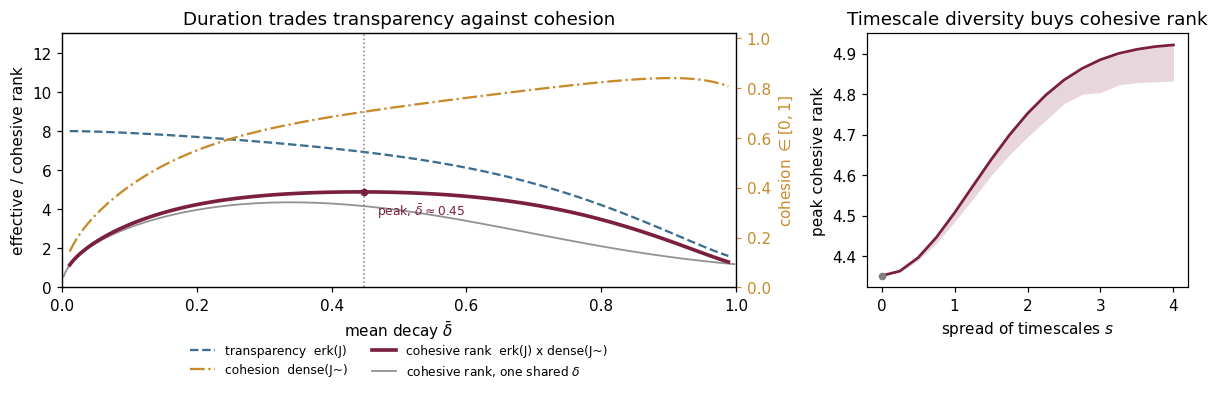

peak cohesive rank: 4.351 (s=0) -> 4.921 (s=4), +13%
variance across gain draws at s=0: 5.1e-30  <- exactly 0, channels collapse


In [13]:
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(11, 3.8),
                               gridspec_kw={"width_ratios": [2.1, 1]})
ax2 = ax1.twinx()

l0, = ax1.plot(mbar0, crank0, "-", color="gray", lw=1.2, alpha=0.85,
               label=r"cohesive rank, one shared $\delta$")
l1, = ax1.plot(mbar, erk_full, "--", color="#3c6e8f", lw=1.5,
               label="transparency  erk(J)")
l3, = ax1.plot(mbar, crank_full, "-", color="#7a1f3d", lw=2.4,
               label="cohesive rank  erk(J) x dense(J~)")
l2, = ax2.plot(mbar, norm_full, "-.", color="#c98a2c", lw=1.5,
               label="cohesion  dense(J~)")

pk = mbar[int(np.argmax(crank_full))]
ax1.axvline(pk, color="gray", ls=":", lw=1)
ax1.plot([pk], [crank_full.max()], "o", ms=4, color="#7a1f3d")
ax1.annotate(f"peak, $\\bar\\delta\\approx${pk:.2f}", xy=(pk + 0.02, crank_full.max() - 0.5),
             fontsize=8, color="#7a1f3d", va="top")
ax1.set_xlim(0, 1); ax1.set_ylim(0, 13); ax2.set_ylim(0, 1.02)
ax1.set_xlabel(r"mean decay $\bar\delta$")
ax1.set_ylabel("effective / cohesive rank")
ax2.set_ylabel("cohesion $\\in[0,1]$", color="#c98a2c")
ax2.tick_params(axis="y", colors="#c98a2c")
ax1.set_title("Duration trades transparency against cohesion")
ax1.legend(handles=[l1, l2, l3, l0], fontsize=8, loc="upper center",
           bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)

# How much does a spread of timescales buy? Solid: unit gains. Band: IQR over
# 40 random positive gain draws.
spreads = np.linspace(0.0, 4.0, 17)
gg = torch.Generator().manual_seed(0)
draws = [torch.exp(0.6 * torch.randn(C, generator=gg)) for _ in range(40)]
peaks_eq, peaks = [], []
for s in spreads:
    ds = [sigmoid(torch.tensor(float(mu)) + float(s) * Z) for mu in mus]
    peaks_eq.append(max(cohesive_rank(ema_jac(d)).item() for d in ds))
    peaks.append([max(cohesive_rank(ema_jac(d, w_in=w)).item() for d in ds) for w in draws])
peaks_eq, peaks = np.array(peaks_eq), np.array(peaks)

ax3.fill_between(spreads, np.percentile(peaks, 25, 1), np.percentile(peaks, 75, 1),
                 color="#7a1f3d", alpha=0.18, lw=0)
ax3.plot(spreads, peaks_eq, "-", color="#7a1f3d", lw=1.8)
ax3.plot([0], [peaks_eq[0]], "o", ms=4, color="gray")
ax3.set_xlabel("spread of timescales $s$")
ax3.set_ylabel("peak cohesive rank")
ax3.set_title("Timescale diversity buys cohesive rank")
fig.tight_layout()
plt.show()

print(f"peak cohesive rank: {peaks_eq[0]:.3f} (s=0) -> {peaks_eq[-1]:.3f} (s=4), "
      f"+{100 * (peaks_eq[-1] / peaks_eq[0] - 1):.0f}%")
print(f"variance across gain draws at s=0: {peaks[0].var():.1e}  <- exactly 0, channels collapse")

Neither extreme wins. A near-scaled-identity (all decays $\to0$) is maximally transparent and weakly cohesive, so cohesive rank is small -- transparent the way a set of unrelated instants is transparent, each perfectly distinct but barely woven to any other. The exactly-diagonal MLP baseline above is the limiting case, with cohesion and cohesive rank both exactly $0$; the EMA never quite gets there, because its off-diagonals are small rather than absent.

The other end is cohesive and barely transparent. Row $t$ of the triangle is the running total of the first $t$ inputs, so the rows are nested prefixes: their norms grow like $\sqrt{t}$, and the first and last rows are far from parallel. What collapses transparency is the nesting itself. Early inputs enter every row while late inputs enter only a few, so the rows pile up along a single direction. The cell below checks this.

The *spread* matters on its own. The right-hand panel holds the sweep fixed and varies only how far apart the channels' timescales are: peak cohesive rank rises monotonically, by about 19% here, and the gain grows with the window ($+12\%$ at $T=8$, $+18\%$ at $T=12$, $+26\%$ at $T=24$). A bank of channels running at *different* speeds weaves a denser knot than any bank running at one speed, because each timescale contributes a differently-shaped band to the triangle and the bands do not lie in each other's span. This is a small, concrete reason for a system that has to hold the past to hold it at several resolutions at once -- which is what synaptic, cellular and network time constants in cortex actually do.

In [14]:
# Why transparency collapses at delta -> 1. The limit is the lower-triangular
# all-ones matrix L, where row t is the running total of the first t inputs.
L = torch.tril(torch.ones(T, T))
U, S, Vt = torch.linalg.svd(L)

rows = L / L.norm(dim=1, keepdim=True)
cos = rows @ rows.T

print("row norms          :", np.round(L.norm(dim=1).numpy(), 3))
print("cos(row_t, row_t+1):", np.round([cos[i, i + 1].item() for i in range(T - 1)], 3))
print(f"cos(row_1, row_{T})   : {cos[0, -1].item():.3f}   <- not parallel: rows are NOT alike")
print()
print("singular values    :", np.round(S.numpy(), 3))
print(f"spectral mass in top direction: {100 * S[0]**2 / (S**2).sum():.1f}%")
print(f"transparency erk(L)           : {transparency(L).item():.3f}")
print("top right-singular vector     :", np.round(Vt[0].abs().numpy(), 3))
print("  ^ a ramp: x_1 enters every row, x_T enters only the last one.")

row norms          : [1.    1.414 1.732 2.    2.236 2.449 2.646 2.828]
cos(row_t, row_t+1): [0.707 0.816 0.866 0.894 0.913 0.926 0.935]
cos(row_1, row_8)   : 0.354   <- not parallel: rows are NOT alike

singular values    : [5.419 1.827 1.122 0.83  0.677 0.588 0.536 0.509]
spectral mass in top direction: 81.6%
transparency erk(L)           : 1.479
top right-singular vector     : [0.483 0.467 0.434 0.387 0.327 0.255 0.175 0.089]
  ^ a ramp: x_1 enters every row, x_T enters only the last one.


The rows are genuinely different -- norms spread over a factor of $\sqrt{T}$ and the extreme rows are far from parallel -- yet a single mode carries most of the spectral mass, and $\mathrm{erk}$ collapses to well under 2. Long memory does not blur everything into one impression; it counts the early past over and over while counting the recent past once.

### 3.3 Vivid and obscure ideas

§"Vivid and obscure ideas" contrasts relu and sigmoid units: sigmoid gradients vanish at saturation, relu gradients don't. More specifically, for a relu net with no biases, $\langle J_{y_i\leftarrow x}, x\rangle = y_i$: the dot product of a facet of experience with the input recovers the output *exactly* -- a precise identity, not just a qualitative "relu gradients don't vanish."

In [15]:
g = torch.Generator().manual_seed(8)
relu_net = nn.Sequential(nn.Linear(4, 6, bias=False), nn.ReLU(), nn.Linear(6, 3, bias=False))
with torch.no_grad():
    for p in relu_net.parameters():
        p.copy_(torch.randn(p.shape, generator=g))
x_v = torch.randn(4, generator=g, requires_grad=True)
y_v = relu_net(x_v)
J_v = jacobian(y_v, x_v)
dots = J_v @ x_v.detach()
print("<J_yi, x> :", dots.detach().numpy().round(4))
print("y_i       :", y_v.detach().numpy().round(4))
print("max abs difference:", (dots - y_v.detach()).abs().max().item())

<J_yi, x> : [-0.8006 -1.4215 -2.0006]
y_i       : [-0.8006 -1.4215 -2.0006]
max abs difference: 4.440892098500626e-16


### 3.4 The experience of attention

A simplified attention layer has a key-query (KQ) path that selects *what* to attend to, and a value-output (VO) path that
transforms and propagates it. When attention is diffuse, gradients flow through both paths. When it concentrates on one key (an attention sink), gradients through the KQ path vanish -- *what* is attended to becomes a settled fact, no longer a live decision.

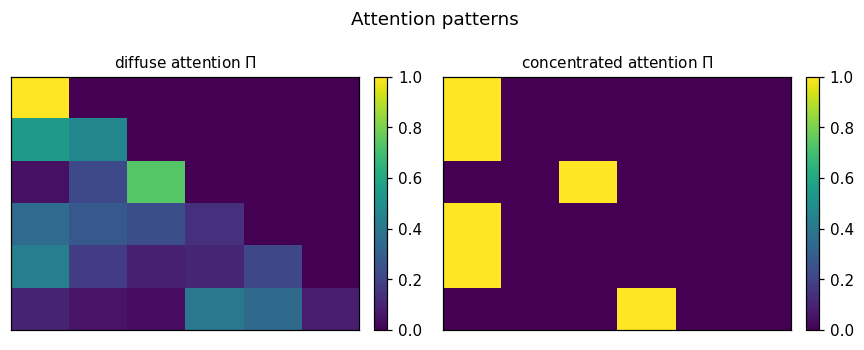

||J_{Pi <- X}|| (diffuse)      : 0.9805756885566226
||J_{Pi <- X}|| (concentrated) : 3.0429138970719363e-08


In [16]:
def simple_attention(X, Wq, Wk, Wv, temperature):
    S = (X @ Wq) @ (X @ Wk).T / temperature
    causal_mask = torch.triu(torch.ones_like(S), diagonal=1).bool()
    S = S.masked_fill(causal_mask, float("-inf"))
    Pi = torch.softmax(S, dim=-1)
    return Pi, Pi @ (X @ Wv)

g = torch.Generator().manual_seed(9)
Tt, d = 6, 4
X = torch.randn(Tt, d, generator=g, requires_grad=True)
Wq, Wk, Wv = (torch.randn(d, d, generator=g) for _ in range(3))

Pi_diffuse, y_diffuse = simple_attention(X, Wq, Wk, Wv, temperature=8.0)
Pi_concentrated, y_concentrated = simple_attention(X, Wq, Wk, Wv, temperature=0.05)

# KQ-path sensitivity: how much does the attention pattern itself move when X moves?
J_kq_diffuse = jacobian(Pi_diffuse, X)
X2 = X.detach().clone().requires_grad_(True)
Pi_concentrated2, _ = simple_attention(X2, Wq, Wk, Wv, temperature=0.05)
J_kq_concentrated = jacobian(Pi_concentrated2, X2)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
heat(axes[0], Pi_diffuse.detach(), "diffuse attention $\\Pi$", cmap="viridis", symmetric=False)
heat(axes[1], Pi_concentrated.detach(), "concentrated attention $\\Pi$", cmap="viridis", symmetric=False)
fig.suptitle("Attention patterns")
fig.tight_layout()
plt.show()

print("||J_{Pi <- X}|| (diffuse)      :", J_kq_diffuse.norm().item())
print("||J_{Pi <- X}|| (concentrated) :", J_kq_concentrated.norm().item())

### 3.5 A blooming buzzing confusion

§"A blooming buzzing confusion" looks at a randomly initialized, deep relu MLP: as depth increases, the overlap between which hidden units are active for nearby inputs decays exponentially, so gradients for nearby inputs decorrelate and the 1D-gradient curve over a grid of inputs looks like white noise.

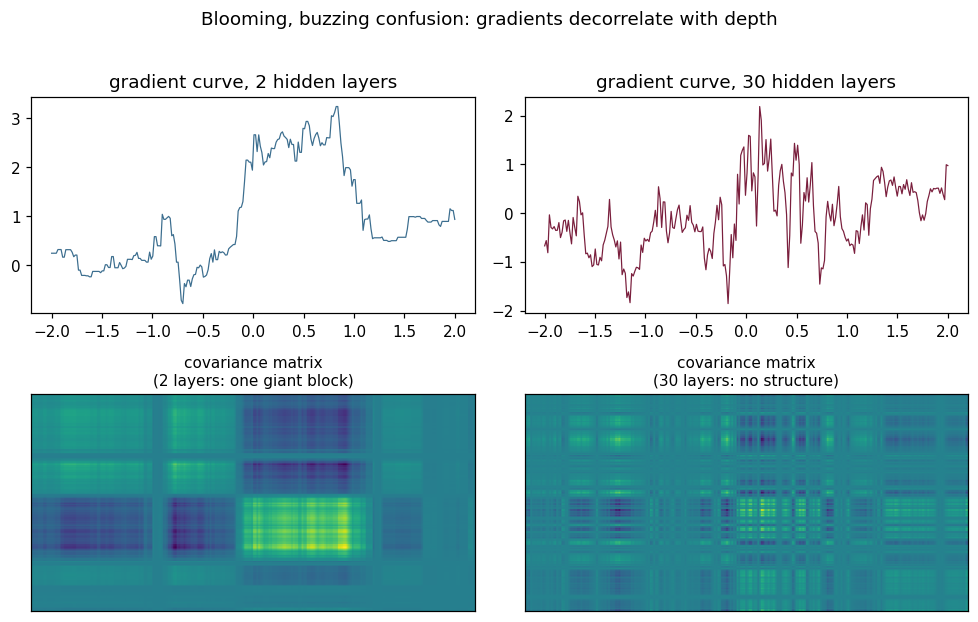

std of gradient curve, shallow: 1.0166203128906453
std of gradient curve, deep   : 0.7146195052486982


In [17]:
def make_deep_relu_mlp(depth, width, generator):
    """He-scaled relu MLP: weights ~ N(0, 2/fan_in), so signal variance is
    preserved layer to layer (unlike `relu_mlp` above, whose fixed 0.8
    scale is fine for the tiny nets used elsewhere but explodes at depth).
    Biases are also random (not zero): with zero bias every hidden unit's
    sign flips exactly at x=0, so the whole net has only *one* breakpoint
    no matter the depth. Random biases spread the breakpoints across the
    input range, which is what actually shatters the gradient."""
    dims = [1] + [width] * depth + [1]
    layers = []
    for i in range(len(dims) - 1):
        layers.append(nn.Linear(dims[i], dims[i + 1]))
        if i < len(dims) - 2:
            layers.append(nn.ReLU())
    net = nn.Sequential(*layers)
    with torch.no_grad():
        for lin in [m for m in net if isinstance(m, nn.Linear)]:
            fan_in = lin.weight.shape[1]
            std = (2.0 / fan_in) ** 0.5
            lin.weight.copy_(torch.randn(lin.weight.shape, generator=generator) * std)
            lin.bias.copy_(torch.randn(lin.bias.shape, generator=generator) * std)
    return net

grid = torch.linspace(-2, 2, 256)

def grid_gradients(net, grid):
    grads = []
    for xi in grid:
        xi = xi.clone().requires_grad_(True)
        y = net(xi.reshape(1))
        grads.append(jacobian(y, xi).item())
    return torch.tensor(grads)

g = torch.Generator().manual_seed(11)
shallow_net = make_deep_relu_mlp(depth=2, width=200, generator=g)
deep_net = make_deep_relu_mlp(depth=30, width=200, generator=g)

grads_shallow = grid_gradients(shallow_net, grid)
grads_deep = grid_gradients(deep_net, grid)

fig, axes = plt.subplots(2, 2, figsize=(9, 5.5))
axes[0, 0].plot(grid.numpy(), grads_shallow.numpy(), color="#3c6e8f", lw=0.8)
axes[0, 0].set_title("gradient curve, 2 hidden layers")
axes[0, 1].plot(grid.numpy(), grads_deep.numpy(), color="#7a1f3d", lw=0.8)
axes[0, 1].set_title("gradient curve, 30 hidden layers")

# "the covariance matrix" of Fig. f:shatter: the outer product of the
# (centered) gradient curve with itself. A smooth curve gives a smooth,
# blocky outer product (nearby points are similar); a shattered, white-noise
# curve gives an outer product that itself looks like structureless noise.
def outer_covariance(grads):
    c = grads - grads.mean()
    return torch.outer(c, c) / c.var().clamp_min(1e-12)

heat(axes[1, 0], outer_covariance(grads_shallow), "covariance matrix\n(2 layers: one giant block)", cmap="viridis", symmetric=False, cbar=False)
heat(axes[1, 1], outer_covariance(grads_deep), "covariance matrix\n(30 layers: no structure)", cmap="viridis", symmetric=False, cbar=False)
fig.suptitle("Blooming, buzzing confusion: gradients decorrelate with depth", y=1.02)
fig.tight_layout()
plt.show()

print("std of gradient curve, shallow:", grads_shallow.std().item())
print("std of gradient curve, deep   :", grads_deep.std().item())

### 3.6 Distinct and confused ideas

§"Distinct and confused ideas" says there are $k$ **distinct ideas** if the coherency matrix $G=JJ^\intercal$ of the
parameter Jacobian is block diagonal with $k$ blocks. This happens when the net's activations split, at some layer, into
circuits that never interact again downstream: $J_{y\leftarrow a_l}$ is what matters, not the raw parameters.

We build a trunk that mixes freely, followed by a split into two branches that read disjoint halves of the trunk's output and never interact again.

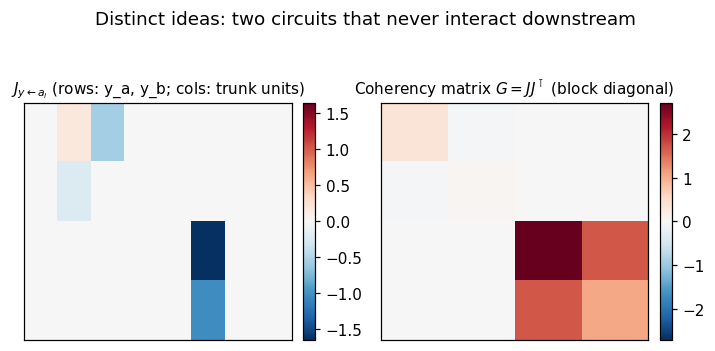

off-block coherency matrix entries (should be exactly 0): 0.0 0.0


In [18]:
class SplitCircuit(nn.Module):
    def __init__(self, d_in, k, out_a, out_b):
        super().__init__()
        self.trunk = nn.Linear(d_in, 2 * k)
        self.branch_a = nn.Linear(k, out_a)
        self.branch_b = nn.Linear(k, out_b)
        self.k = k

    def forward(self, x):
        a = torch.relu(self.trunk(x))          # shared, mixed trunk activation
        ya = self.branch_a(a[:self.k])          # only reads the first half
        yb = self.branch_b(a[self.k:])          # only reads the second half
        return torch.cat([ya, yb])

g = torch.Generator().manual_seed(12)
circuit = SplitCircuit(d_in=3, k=4, out_a=2, out_b=2)
with torch.no_grad():
    for p in circuit.parameters():
        p.copy_(torch.randn(p.shape, generator=g))
x_c = torch.randn(3, generator=g)

with capture(circuit, ["trunk"]) as cap:
    y_c = circuit(x_c)
# J_{y<-a_l}: Jacobian from the trunk's (pre-relu) pre-activation to the output.
J_al = jacobian(y_c, cap["trunk"])
G = J_al @ J_al.T

fig, axes = plt.subplots(1, 2, figsize=(6.5, 3))
heat(axes[0], J_al, "$J_{y\\leftarrow a_l}$ (rows: y_a, y_b; cols: trunk units)")
heat(axes[1], G, "Coherency matrix $G=JJ^\\intercal$ (block diagonal)")
fig.suptitle("Distinct ideas: two circuits that never interact downstream", y=1.05)
fig.tight_layout()
plt.show()

print("off-block coherency matrix entries (should be exactly 0):", G[:2, 2:].abs().max().item(), G[2:, :2].abs().max().item())

### A cohesive matrix with a diagonal coherency matrix

Right after defining distinct ideas, the paper notes "a block diagonal coherency matrix does not imply the Jacobian is block diagonal. Distinctness and cohesion are not directly related". To see this: take the SVD $A=UDV^\intercal$ of a random matrix and set $B:=DV^\intercal$ (i.e. drop the output rotation $U$). Then $G=BB^\intercal=DV^\intercal VD^\intercal=D^2$ is *exactly diagonal* -- the maximally distinct case, $n$ singleton blocks -- while $B$ itself is generically dense and has exactly the same singular values, hence the same transparency, as $A$.

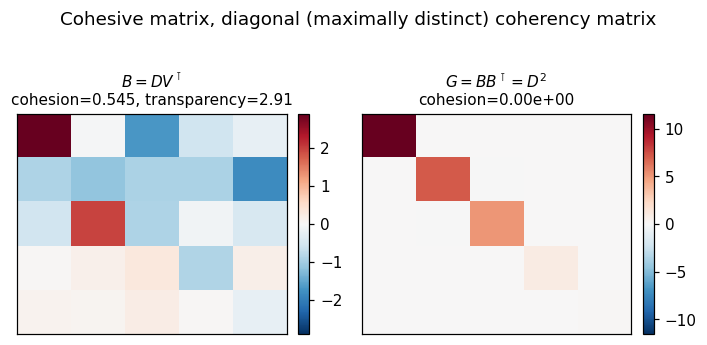

max |G - diag(S^2)| = 1.7763568394002505e-15
transparency(A) == transparency(B): 2.912278846158442 vs 2.912278846158442


In [19]:
g = torch.Generator().manual_seed(20)
n = 5
A_svd = torch.randn(n, n, generator=g)
U, S, Vt = torch.linalg.svd(A_svd)
B = torch.diag(S) @ Vt
G_diag = B @ B.T

fig, axes = plt.subplots(1, 2, figsize=(6.5, 3))
heat(axes[0], B, f"$B=DV^\\intercal$\ncohesion={cohesion(B).item():.3f}, transparency={transparency(B).item():.2f}")
heat(axes[1], G_diag, f"$G=BB^\\intercal=D^2$\ncohesion={cohesion(G_diag).item():.2e}")
fig.suptitle("Cohesive matrix, diagonal (maximally distinct) coherency matrix", y=1.03)
fig.tight_layout()
plt.show()

print("max |G - diag(S^2)| =", (G_diag - torch.diag(S ** 2)).abs().max().item())
print("transparency(A) == transparency(B):", transparency(A_svd).item(), "vs", transparency(B).item())

`B` is exactly as transparent as `A` (same singular values), and -- being a generic rotation `Vt` rescaled row-by-row -- is dense and cohesive. Yet its coherency matrix is exactly `diag(S^2)`: as distinct as $n$ output neurons can possibly be. Distinctness lives in the coherency matrix $JJ^\intercal$; cohesion lives in $J$ itself; the appendix's point is that these are simply different questions.

## 4. The metabolic channel

Here the net has an energy budget. The budget leaks away, is replenished by what 
the net has been doing, and modulates its outputs:
\begin{align*}
  E_t &= (1-\rho)\,E_{t-1} + \gamma\,\mathrm{feed}(y_{t-1}) && \text{leaky-integrator reserve}\\
  m_t &= g(E_t) = \frac{E_t}{E_t + E_0} && \text{concave, saturating capability}\\
  y_t &= m_t\, u_t && \text{experience, gain-modulated}
\end{align*}
$u_t=\langle \mathbf{r},\mathbf{h}_t\rangle$ is the raw experience of an ordinary
recurrent net -- the sort of thing §3.2 took Jacobians of. $E$ is a reserve that
leaks at rate $\rho$ and is fed by what was felt a moment ago. $m\in(0,1)$ is
capability, concave in the reserve, so the first units of energy buy far more
than the last.

Energy never enters experience directly, then; it enters only as a *gain* on it.
That is what makes it tractable, because a gain multiplies, and the chain rule
can pull a multiplier out as a factor.

The section runs the same recipe as §3.2 -- write the mechanism down, take the
Jacobian, factor it, ask how transparent the factor is -- with the factor here
being everything metabolism contributes. Three questions, in order: **is the
factorization exact?** **how many independent directions does the metabolic path
carry?** and **when is it loud?**

Because $m_t$ multiplies $u_t$, the Jacobian splits into two *additive* paths,
\begin{equation*}
  J \;=\; J_{\rm cut} \;+\; D,
\end{equation*}
where $J_{\rm cut}$ is the Jacobian with the energy path severed -- $y_{t-1}$
detached at the point where it feeds the reserve, so the forward values are
untouched and only the gradient path through energy disappears -- and $D$ is
everything metabolism adds. That second term factors exactly:
\begin{equation*}
  D = \mathrm{diag}(c)\,R\,J, \qquad
  c_t = u_t\, g'(E_t), \qquad
  R_{tk} = \gamma\,\mathrm{feed}'(y_k)\,(1-\rho)^{t-1-k}.
\end{equation*}
Three factors worth naming separately. $J$ is what is felt. $R$ accumulates that
into the reserve, with a geometric memory of rate $1-\rho$. And
$\mathrm{diag}(c)$ reads the reserve back out as a per-moment gain -- call $c_t$
the **salience** of moment $t$, how much a nudge to the reserve at $t$ moves what
is felt at $t$.

The next cell writes the mechanism down verbatim; `run` is the forward pass, and
`pieces` returns $J$, $J_{\rm cut}$, $D$, $R$, $c$ and the reserve trajectory
for one net and one feed strength $\gamma$.

In [20]:
# The mechanism of section 4: a small recurrent net whose output is gated by a
# leaky energy reserve that its own output feeds.
import torch.nn.functional as F      # softplus, for the reserve's feed term

Tm = 12                              # window length for this example
RHO, E0 = 0.5, 0.35                  # leak rate of the reserve; half-saturation of g
GAMMAS = (0.10, 0.18, 0.28, 0.40)    # how strongly experience feeds the reserve


def build_net(seed, d=6):
    """Random weights for the recurrent net that produces the raw experience u."""
    gg = torch.Generator().manual_seed(seed)
    W_hh = torch.randn(d, d, generator=gg) * 0.55
    W_xh = torch.randn(d, generator=gg) * 0.9
    r = torch.randn(d, generator=gg) * 0.7
    return W_hh, W_xh, r


def run(xs, W, gamma, cut=False):
    """h_t = tanh(W_hh h_{t-1} + W_xh x_t),  u_t = <r, h_t>    raw experience
       E_t = (1 - RHO) E_{t-1} + gamma softplus(y_{t-1})       leaky reserve
       m_t = E_t / (E_t + E0)                                  capability
       y_t = m_t u_t                                           what is felt

    `cut=True` detaches y_{t-1} where it feeds the reserve: the forward values are
    identical, only the gradient path through energy is severed.
    """
    W_hh, W_xh, r = W
    h = torch.zeros(W_hh.shape[0])
    E = torch.tensor(0.3)
    y_prev = torch.zeros(())
    ys, cs, Es, gains = [], [], [], []
    for t in range(Tm):
        h = torch.tanh(W_hh @ h + W_xh * xs[t])
        u = (r * h).sum()
        y_fed = y_prev.detach() if cut else y_prev
        gains.append(gamma * torch.sigmoid(y_fed))       # gamma * feed'(y_{t-1})
        E = (1 - RHO) * E + gamma * F.softplus(y_fed)
        m = E / (E + E0)                                 # capability
        cs.append(u * E0 / (E + E0) ** 2)                # c_t = u_t g'(E_t)
        Es.append(E)
        y = m * u
        ys.append(y)
        y_prev = y
    return tuple(torch.stack(v) for v in (ys, cs, Es, gains))


def pieces(W, xs, gamma):
    """J (full), J_cut (energy path severed), D = J - J_cut, the accumulation
    matrix R, the salience vector c, and the reserve trajectory E."""
    x1 = xs.clone().requires_grad_(True)
    y, c, E, gains = run(x1, W, gamma)
    J = jacobian(y, x1).detach()

    x2 = xs.clone().requires_grad_(True)
    J_cut = jacobian(run(x2, W, gamma, cut=True)[0], x2).detach()

    R = torch.zeros(Tm, Tm)               # R_tk = gamma feed'(y_k) (1 - RHO)^(t-1-k)
    for t in range(Tm):
        for k in range(t):
            R[t, k] = gains[k + 1] * (1 - RHO) ** (t - 1 - k)
    return J, J_cut, (J - J_cut), R.detach(), c.detach(), E.detach()

max |D - diag(c) R J| = 3.6e-16   <- exact, not an approximation
share of ||J||^2 carried by the metabolic path: 0.031


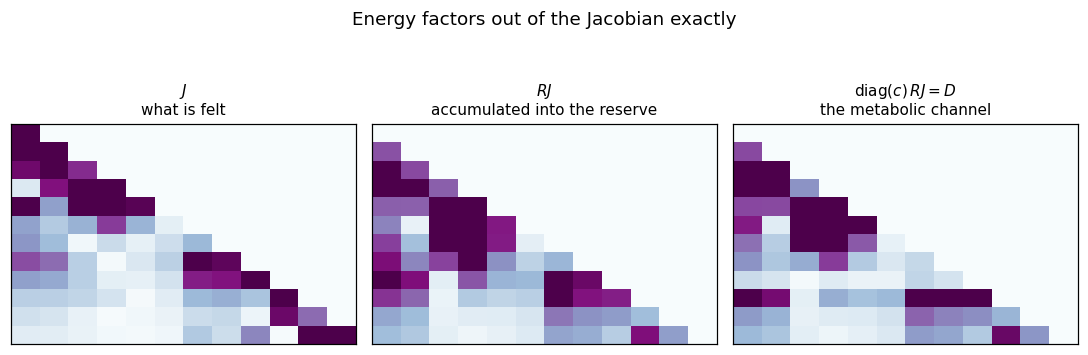

transparency: erk(J_cut) = 4.76, erk(D) = 2.28


In [21]:
# Question 1: is D = diag(c) R J exact? And what does each factor do to the
# picture? One net, one feed strength; matrices shown as |entry| / mean|entry|,
# so the comparison is about shape rather than scale.
W0 = build_net(11)
xs0 = torch.randn(Tm, generator=torch.Generator().manual_seed(100))
J_met, J_cut, D, R, c, E = pieces(W0, xs0, gamma=0.28)
RJ = R @ J_met

print(f"max |D - diag(c) R J| = {(D - torch.diag(c) @ RJ).abs().max().item():.1e}"
      "   <- exact, not an approximation")
print(f"share of ||J||^2 carried by the metabolic path: "
      f"{(D.norm() ** 2 / J_met.norm() ** 2).item():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, X, ttl, note in zip(
        axes, (J_met, RJ, D),
        (r"$J$", r"$RJ$", r"$\mathrm{diag}(c)\,RJ=D$"),
        ("what is felt", "accumulated into the reserve", "the metabolic channel")):
    A = X.abs().numpy()
    A = np.minimum(A / max(A.mean(), 1e-30), 3.0)   # scale-free, clipped for contrast
    heat(ax, A, f"{ttl}\n{note}", cmap="BuPu", symmetric=False, cbar=False)
fig.suptitle("Energy factors out of the Jacobian exactly", y=1.06)
fig.tight_layout()
plt.show()

print(f"transparency: erk(J_cut) = {transparency(J_cut).item():.2f}, "
      f"erk(D) = {transparency(D).item():.2f}")

Reading left to right: each row of $RJ$ is a geometrically decaying sum of the
*earlier* rows of $J$, so the sharp diagonal of $J$ smears backwards into a band;
$\mathrm{diag}(c)$ then rescales row $t$ by the salience of that moment. Two
features of $D$ itself: its first row is exactly zero -- the reserve at $t=0$
predates every input -- and it is far fainter than $J$, carrying only a few
percent of the squared gradient mass.

Faint is not the same as unstructured, though, and the shape is the interesting
part. The cell below puts questions 2 and 3 to a sweep of 10 random nets $\times$
4 feed strengths $\gamma$: how many independent directions $D$ carries, whether
that number is predictable, and how salience varies with capability.

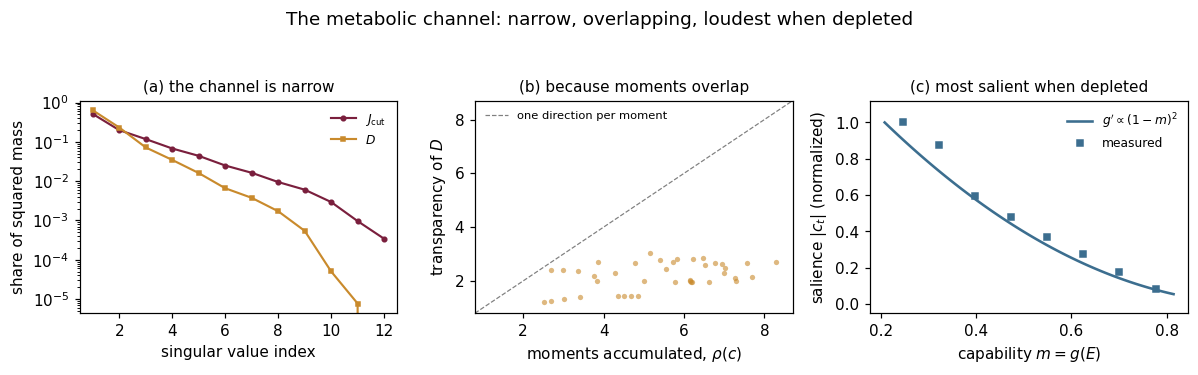

metabolic share of ||J||^2      : 0.024
erk(D) 2.19 vs erk(J_cut) 3.23  -- D is narrower in 75% of runs
top mode carries 63% of D, 51% of J_cut
moments accumulated, rho(c)     : 5.36   (corr with erk(D): +0.45)
corr(|c|, m) = -0.510; |c| is 3.8x larger in the bottom quartile of capability than the top


In [22]:
# Questions 2 and 3, over 10 nets x 4 feed strengths:
#   (a) how narrow is the metabolic channel, spectrally, next to J_cut?
#   (b) is its transparency predicted by rho(c), the participation ratio of the
#       salience vector -- i.e. the number of moments that meaningfully count?
#   (c) how does salience |c_t| depend on capability m?
NSEED = 10
PR, erk_D, erk_cut, share = [], [], [], []
spec_D, spec_cut, caps, sal = [], [], [], []

for s in range(NSEED):
    W = build_net(11 + s)
    xs = torch.randn(Tm, generator=torch.Generator().manual_seed(100 + s))
    for gamma in GAMMAS:
        J_, Jc_, D_, R_, c_, E_ = pieces(W, xs, gamma)
        c2 = c_ ** 2
        PR.append((c2.sum() ** 2 / (c2 ** 2).sum()).item())   # rho(c)
        erk_D.append(transparency(D_).item())
        erk_cut.append(transparency(Jc_).item())
        share.append((D_.norm() ** 2 / J_.norm() ** 2).item())
        caps += list((E_ / (E_ + E0)).numpy())
        sal += list(c_.abs().numpy())
        if gamma == 0.28:
            for X, acc in ((D_, spec_D), (Jc_, spec_cut)):
                v = torch.linalg.svdvals(X) ** 2
                acc.append((v / v.sum()).numpy())

PR, erk_D, erk_cut, share = map(np.array, (PR, erk_D, erk_cut, share))
spec_D, spec_cut = np.array(spec_D), np.array(spec_cut)
caps, sal = np.array(caps), np.array(sal)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

ax = axes[0]                                        # (a) how narrow is the channel?
idx = np.arange(1, Tm + 1)
ax.plot(idx, spec_cut.mean(0), "o-", color="#7a1f3d", ms=3, lw=1.4, label=r"$J_{\rm cut}$")
ax.plot(idx, spec_D.mean(0), "s-", color="#c98a2c", ms=3, lw=1.4, label=r"$D$")
ax.set_yscale("log"); ax.set_xlim(0.5, Tm + 0.5)
ax.set_xlabel("singular value index")
ax.set_ylabel("share of squared mass")
ax.set_title("(a) the channel is narrow", fontsize=10)
ax.legend(fontsize=8, frameon=False)

ax = axes[1]                                        # (b) narrow because moments overlap
hi = max(PR.max(), erk_D.max()) * 1.05
ax.plot([0.8, hi], [0.8, hi], color="gray", lw=0.8, ls="--",
        label="one direction per moment")
ax.scatter(PR, erk_D, s=12, color="#c98a2c", alpha=0.6, linewidths=0)
ax.set_xlim(0.8, hi); ax.set_ylim(0.8, hi)
ax.set_xlabel(r"moments accumulated, $\rho(c)$")
ax.set_ylabel("transparency of $D$")
ax.set_title("(b) because moments overlap", fontsize=10)
ax.legend(fontsize=7.5, frameon=False, loc="upper left")

ax = axes[2]                                        # (c) when is energy loud?
edges = np.linspace(caps.min(), caps.max(), 9)
bx, by = [], []
for i in range(len(edges) - 1):
    sel = (caps >= edges[i]) & (caps < edges[i + 1])
    if sel.sum() >= 8:
        bx.append(0.5 * (edges[i] + edges[i + 1])); by.append(sal[sel].mean())
bx, by = np.array(bx), np.array(by) / max(by)
grid = np.linspace(caps.min(), caps.max(), 100)
pred = (1 - grid) ** 2; pred = pred / pred.max()
ax.plot(grid, pred, "-", color="#3c6e8f", lw=1.7, label=r"$g'\propto(1-m)^2$")
ax.plot(bx, by, "s", color="#3c6e8f", ms=4, label="measured")
ax.set_ylim(-0.05, 1.12)
ax.set_xlabel("capability $m=g(E)$")
ax.set_ylabel("salience $|c_t|$ (normalized)")
ax.set_title("(c) most salient when depleted", fontsize=10)
ax.legend(fontsize=8, frameon=False)

fig.suptitle("The metabolic channel: narrow, overlapping, loudest when depleted", y=1.05)
fig.tight_layout()
plt.show()

q1, q3 = np.quantile(caps, 0.25), np.quantile(caps, 0.75)
print(f"metabolic share of ||J||^2      : {share.mean():.3f}")
print(f"erk(D) {erk_D.mean():.2f} vs erk(J_cut) {erk_cut.mean():.2f}"
      f"  -- D is narrower in {100 * np.mean(erk_D < erk_cut):.0f}% of runs")
print(f"top mode carries {100 * spec_D.mean(0)[0]:.0f}% of D, "
      f"{100 * spec_cut.mean(0)[0]:.0f}% of J_cut")
print(f"moments accumulated, rho(c)     : {PR.mean():.2f}"
      f"   (corr with erk(D): {np.corrcoef(PR, erk_D)[0, 1]:+.2f})")
print(f"corr(|c|, m) = {np.corrcoef(sal, caps)[0, 1]:+.3f}; |c| is "
      f"{sal[caps < q1].mean() / sal[caps > q3].mean():.1f}x larger in the bottom "
      f"quartile of capability than the top")

Three answers.

**(a) The channel is narrow.** $D$'s spectrum falls away far faster than
$J_{\rm cut}$'s: its leading mode carries about 63% of the squared mass against
51%, and its top two carry 86% against 71%. In effective-rank terms
$\mathrm{erk}(D)\approx2.2$ against $\mathrm{erk}(J_{\rm cut})\approx3.2$, and $D$
is the narrower of the two in three runs out of four. Metabolism is not a broad
new tract of experience; it is one or two directions.

**(b) Narrow because the moments overlap.** The dashed line in panel (b) is the
reference for a channel that gains a fresh direction from every moment it
accumulates -- $\rho(c) = (\sum_t c_t^2)^2 / \sum_t c_t^4$, the participation
ratio of the salience vector, counts those moments, and averages about 5.4 here.
The points never reach the line. Transparency of $D$ is below $\rho(c)$ in every
run, about $0.44\times$ it on average, and climbs only weakly as more moments
join in (correlation $\approx0.45$). The reason is that every row of $R$ is the
*same* geometric kernel, shifted and reweighted, so successive rows of $D$ read
the same reserve instead of contributing independent directions.

**(c) Loudest when depleted.** For $g(E)=E/(E+E_0)$ the derivative is
$g'(E) = E_0/(E+E_0)^2 = (1-m)^2/E_0$, so salience is exactly quadratic in the
shortfall $1-m$ -- and the binned measurements land on that curve. Salience is
about four times larger in the bottom quartile of capability than in the top.
Near saturation, more reserve changes almost nothing about what is felt; near
empty, it changes nearly everything.

Together: energy does not widen experience. It modulates it along one or two
slowly-varying directions whose volume is set by how depleted the system already
is -- which is why a capacity that is spent and replenished shows up in the
Jacobian as a factor rather than as a new set of facets.